In [1]:
!pip install pandas nltk spacy matplotlib seaborn textstat


Defaulting to user installation because normal site-packages is not writeable
  Using cached spacy-3.8.14-cp313-cp313-win_amd64.whl.metadata (28 kB)
  Using cached textstat-0.7.13-py3-none-any.whl.metadata (15 kB)
  Using cached spacy_legacy-3.0.12-py2.py3-none-any.whl.metadata (2.8 kB)
  Using cached spacy_loggers-1.0.5-py3-none-any.whl.metadata (23 kB)
  Using cached murmurhash-1.0.15-cp313-cp313-win_amd64.whl.metadata (2.3 kB)
  Using cached cymem-2.0.13-cp313-cp313-win_amd64.whl.metadata (9.9 kB)
  Using cached preshed-3.0.13-cp313-cp313-win_amd64.whl.metadata (5.4 kB)
  Using cached thinc-8.3.13-cp313-cp313-win_amd64.whl.metadata (15 kB)
  Using cached wasabi-1.1.3-py3-none-any.whl.metadata (28 kB)
  Using cached srsly-2.5.3-cp313-cp313-win_amd64.whl.metadata (20 kB)
  Using cached catalogue-2.0.10-py3-none-any.whl.metadata (14 kB)
  Using cached weasel-1.0.0-py3-none-any.whl.metadata (4.6 kB)
  Using cached confection-1.3.3-py3-none-any.whl.metadata (19 kB)
  Using cached blis-1.

  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.


In [2]:
!python -m spacy download en_core_web_sm

Defaulting to user installation because normal site-packages is not writeable
     ---------------------------------------- 0.0/12.8 MB ? eta -:--:--
     -- ------------------------------------- 0.8/12.8 MB 7.3 MB/s eta 0:00:02
     ---- ----------------------------------- 1.6/12.8 MB 4.4 MB/s eta 0:00:03
     ------- -------------------------------- 2.4/12.8 MB 4.2 MB/s eta 0:00:03
     --------- ------------------------------ 3.1/12.8 MB 4.1 MB/s eta 0:00:03
     ------------- -------------------------- 4.2/12.8 MB 4.1 MB/s eta 0:00:03
     -------------- ------------------------- 4.7/12.8 MB 4.1 MB/s eta 0:00:02
     ----------------- ---------------------- 5.5/12.8 MB 3.9 MB/s eta 0:00:02
     ------------------- -------------------- 6.3/12.8 MB 4.0 MB/s eta 0:00:02
     ---------------------- ----------------- 7.3/12.8 MB 4.0 MB/s eta 0:00:02
     ------------------------- -------------- 8.1/12.8 MB 3.9 MB/s eta 0:00:02
     --------------------------- ------------ 8.9/12.8 MB 4.

In [4]:
import pandas as pd
import nltk
import spacy
import textstat
import matplotlib.pyplot as plt
import seaborn as sns

from nltk.tokenize import word_tokenize
from collections import Counter

nltk.download("punkt")

nlp = spacy.load("en_core_web_sm")

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\bisho\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!


In [5]:
import spacy

print(spacy.__version__)

3.8.14


In [6]:
import spacy

nlp = spacy.load("en_core_web_sm")

print("Loaded successfully!")

Loaded successfully!


In [55]:
import glob

files = glob.glob("datasets/*.csv")
print(files)

['datasets\\dataset_Class3_Class_Society_and_Social_Evolution_Charles_Dickens.csv', 'datasets\\dataset_Class3_Crime_and_Justice_Charles_Dickens.csv', 'datasets\\dataset_Class3_Human_Nature_and_Morality_Charles_Dickens.csv', 'datasets\\dataset_Class3_Imperialism_and_Colonialism_Charles_Dickens.csv', 'datasets\\dataset_Class3_Scientific_Discovery_and_Technology_Charles_Dickens.csv', 'datasets\\dataset_Class_Society_and_Social_Evolution.csv', 'datasets\\dataset_Crime_and_Justice.csv', 'datasets\\dataset_Human_Class_Society_and_Social_Evolution.csv', 'datasets\\dataset_Human_Crime_and_Justice.csv', 'datasets\\dataset_Human_Human_Nature_and_Morality.csv', 'datasets\\dataset_Human_Imperialism_and_Colonialism.csv', 'datasets\\dataset_Human_Nature_and_Morality.csv', 'datasets\\dataset_Human_Scientific_Discovery_and_Technology.csv', 'datasets\\dataset_Imperialism_and_Colonialism.csv', 'datasets\\dataset_Scientific_Discovery_and_Technology.csv']


In [56]:
import glob

files = glob.glob("datasets/*.csv")

human_files = []
ai_files = []

for file in files:

    filename = file.lower()

    # Class 1 (Human)
    if "dataset_human" in filename:
        human_files.append(file)

    # Class 2 + Class 3 (AI)
    else:
        ai_files.append(file)

print("========== HUMAN FILES ==========")
for f in human_files:
    print(f)

print("\n========== AI FILES ==========")
for f in ai_files:
    print(f)

========== HUMAN FILES ==========
datasets\dataset_Human_Class_Society_and_Social_Evolution.csv
datasets\dataset_Human_Crime_and_Justice.csv
datasets\dataset_Human_Human_Nature_and_Morality.csv
datasets\dataset_Human_Imperialism_and_Colonialism.csv
datasets\dataset_Human_Nature_and_Morality.csv
datasets\dataset_Human_Scientific_Discovery_and_Technology.csv

========== AI FILES ==========
datasets\dataset_Class3_Class_Society_and_Social_Evolution_Charles_Dickens.csv
datasets\dataset_Class3_Crime_and_Justice_Charles_Dickens.csv
datasets\dataset_Class3_Human_Nature_and_Morality_Charles_Dickens.csv
datasets\dataset_Class3_Imperialism_and_Colonialism_Charles_Dickens.csv
datasets\dataset_Class3_Scientific_Discovery_and_Technology_Charles_Dickens.csv
datasets\dataset_Class_Society_and_Social_Evolution.csv
datasets\dataset_Crime_and_Justice.csv
datasets\dataset_Imperialism_and_Colonialism.csv
datasets\dataset_Scientific_Discovery_and_Technology.csv


In [57]:
import pandas as pd

ai_frames = []

for file in ai_files:
    df = pd.read_csv(file)
    ai_frames.append(df)

ai_df = pd.concat(ai_frames, ignore_index=True)

ai_df.head()

,Topic,Paragraph,Class
0,"Class, Society, and Social Evolution",The great engine of society grinds on with a r...,AI_Stylized_Charles_Dickens
1,"Class, Society, and Social Evolution","Behold the march of the ages, a procession led...",AI_Stylized_Charles_Dickens
2,"Class, Society, and Social Evolution",The great engine of society grinds on with a r...,AI_Stylized_Charles_Dickens
3,"Class, Society, and Social Evolution","Observe the tapestry of our age, woven with th...",AI_Stylized_Charles_Dickens
4,"Class, Society, and Social Evolution","The great engine of society grinds on, a monst...",AI_Stylized_Charles_Dickens


In [58]:
import pandas as pd

human_frames = []

for file in human_files:
    df = pd.read_csv(file)
    human_frames.append(df)

human_df = pd.concat(human_frames, ignore_index=True)

human_df.head()

,Topic,Paragraph,Class
0,"Class, Society, and Social Evolution","“Come along, Doctor,” he said; “we shall go an...",Human
1,"Class, Society, and Social Evolution","She was seated by the open window, dressed in ...",Human
2,"Class, Society, and Social Evolution","“‘Consider, Sahib,’ said he, ‘that if this man...",Human
3,"Class, Society, and Social Evolution",“The writing on the wall was done with a man’s...,Human
4,"Class, Society, and Social Evolution",But the dining-room which opened out of the ha...,Human


In [59]:
print(ai_df.shape)
print(human_df.shape)

print(ai_df.columns)
print(human_df.columns)

(450, 3)
(300, 3)
Index(['Topic', 'Paragraph', 'Class'], dtype='object')
Index(['Topic', 'Paragraph', 'Class'], dtype='object')


In [60]:
human_text = " ".join(human_df["Paragraph"])
ai_text = " ".join(ai_df["Paragraph"])

print(len(human_text))
print(len(ai_text))

238096
442832


In [61]:
import nltk

nltk.download("punkt")
nltk.download("punkt_tab")

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\bisho\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\bisho\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


True

In [62]:
from nltk.tokenize import word_tokenize

human_tokens = word_tokenize(human_text.lower())
ai_tokens = word_tokenize(ai_text.lower())

print("Human Tokens:", len(human_tokens))
print("AI Tokens:", len(ai_tokens))

Human Tokens: 46442
AI Tokens: 74203


In [63]:
human_words = [word for word in human_tokens if word.isalpha()]
ai_words = [word for word in ai_tokens if word.isalpha()]

print("Human Words:", len(human_words))
print("AI Words:", len(ai_words))

Human Words: 40714
AI Words: 66248


In [64]:
human_unique = set(human_words)
ai_unique = set(ai_words)

print("Human Unique Words:", len(human_unique))
print("AI Unique Words:", len(ai_unique))

Human Unique Words: 4305
AI Unique Words: 6533


In [65]:
human_ttr = len(human_unique) / len(human_words)
ai_ttr = len(ai_unique) / len(ai_words)

print(f"Human TTR: {human_ttr:.4f}")
print(f"AI TTR: {ai_ttr:.4f}")

Human TTR: 0.1057
AI TTR: 0.0986


In [66]:
human_sample = human_words[:5000]
ai_sample = ai_words[:5000]

print(len(human_sample))
print(len(ai_sample))

5000
5000


In [67]:
from collections import Counter

human_counter = Counter(human_sample)
ai_counter = Counter(ai_sample)

print("Human Unique Words:", len(human_counter))
print("AI Unique Words:", len(ai_counter))

Human Unique Words: 996
AI Unique Words: 1306


In [68]:
human_hapax = sum(1 for word, count in human_counter.items() if count == 1)
ai_hapax = sum(1 for word, count in ai_counter.items() if count == 1)

print("Human Hapax Legomena:", human_hapax)
print("AI Hapax Legomena:", ai_hapax)

Human Hapax Legomena: 405
AI Hapax Legomena: 780


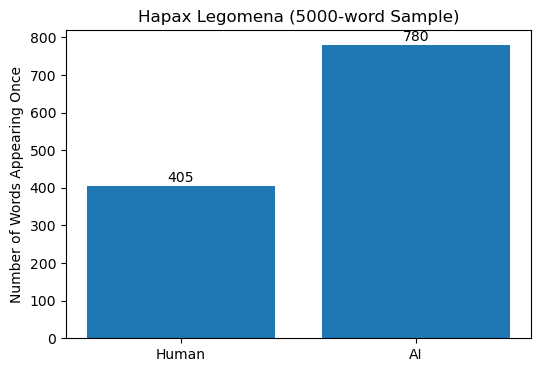

In [69]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))

plt.bar(["Human", "AI"], [human_hapax, ai_hapax])

plt.title("Hapax Legomena (5000-word Sample)")
plt.ylabel("Number of Words Appearing Once")

for i, value in enumerate([human_hapax, ai_hapax]):
    plt.text(i, value + 10, str(value), ha="center")

plt.show()

In [70]:
import spacy

nlp = spacy.load("en_core_web_sm")

print("SpaCy model loaded successfully!")

SpaCy model loaded successfully!


In [71]:
import spacy

print(spacy.__version__)

3.8.14


In [72]:
import spacy

nlp = spacy.load("en_core_web_sm")

print(nlp)

In [73]:
human_doc = nlp(human_text)
ai_doc = nlp(ai_text)

print("Processing completed!")

Processing completed!


In [74]:
human_adj = 0
human_noun = 0

for token in human_doc:
    if token.pos_ == "ADJ":
        human_adj += 1
    elif token.pos_ == "NOUN":
        human_noun += 1

ai_adj = 0
ai_noun = 0

for token in ai_doc:
    if token.pos_ == "ADJ":
        ai_adj += 1
    elif token.pos_ == "NOUN":
        ai_noun += 1

print("Human Adjectives:", human_adj)
print("Human Nouns:", human_noun)

print("AI Adjectives:", ai_adj)
print("AI Nouns:", ai_noun)

Human Adjectives: 3842
Human Nouns: 8254
AI Adjectives: 9328
AI Nouns: 19377


In [75]:
human_ratio = human_adj / human_noun
ai_ratio = ai_adj / ai_noun

print(f"Human Adjective/Noun Ratio: {human_ratio:.4f}")
print(f"AI Adjective/Noun Ratio: {ai_ratio:.4f}")

Human Adjective/Noun Ratio: 0.4655
AI Adjective/Noun Ratio: 0.4814


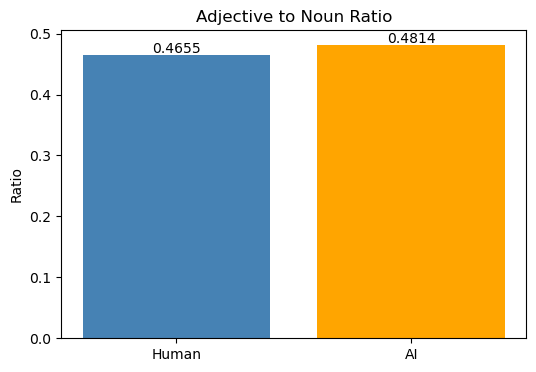

In [76]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))

plt.bar(
    ["Human", "AI"],
    [human_ratio, ai_ratio],
    color=["steelblue", "orange"]
)

plt.title("Adjective to Noun Ratio")
plt.ylabel("Ratio")

for i, value in enumerate([human_ratio, ai_ratio]):
    plt.text(i, value + 0.003, f"{value:.4f}", ha="center")

plt.show()

In [77]:
human_depths = []

for sent in human_doc.sents:
    depth = max([token.i - sent.start for token in sent], default=0)
    human_depths.append(depth)

print("Human sentences:", len(human_depths))

Human sentences: 1964


In [78]:
ai_depths = []

for sent in ai_doc.sents:
    depth = max([token.i - sent.start for token in sent], default=0)
    ai_depths.append(depth)

print("AI sentences:", len(ai_depths))

AI sentences: 2297


In [79]:
import numpy as np

human_avg_depth = np.mean(human_depths)
ai_avg_depth = np.mean(ai_depths)

print(f"Human Average Dependency Depth: {human_avg_depth:.2f}")
print(f"AI Average Dependency Depth: {ai_avg_depth:.2f}")

Human Average Dependency Depth: 24.36
AI Average Dependency Depth: 31.78


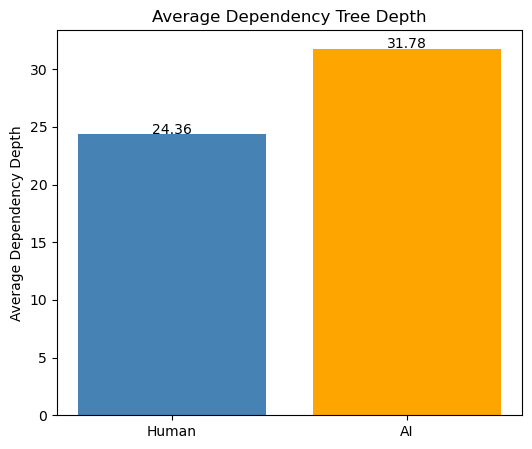

In [80]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,5))

plt.bar(
    ["Human", "AI"],
    [human_avg_depth, ai_avg_depth],
    color=["steelblue", "orange"]
)

plt.ylabel("Average Dependency Depth")
plt.title("Average Dependency Tree Depth")

for i, v in enumerate([human_avg_depth, ai_avg_depth]):
    plt.text(i, v + 0.05, f"{v:.2f}", ha="center")

plt.show()

In [81]:
from collections import Counter
import string
human_punct = Counter(ch for ch in human_text if ch in string.punctuation)
ai_punct = Counter(ch for ch in ai_text if ch in string.punctuation)

print("Human punctuation:")
print(human_punct)

print("\nAI punctuation:")
print(ai_punct)

Human punctuation:
Counter({',': 2672, '.': 1993, '-': 283, '_': 48, '?': 45, ';': 41, "'": 23, '!': 17, ':': 9, '"': 8})

AI punctuation:
Counter({',': 4917, '.': 2274, '-': 544, "'": 71, ';': 32, '"': 20, '?': 19, '!': 3, ':': 1, '(': 1, ')': 1})


In [82]:
human_total = sum(human_punct.values())
ai_total = sum(ai_punct.values())

print("Human Total Punctuation:", human_total)
print("AI Total Punctuation:", ai_total)

Human Total Punctuation: 5139
AI Total Punctuation: 7883


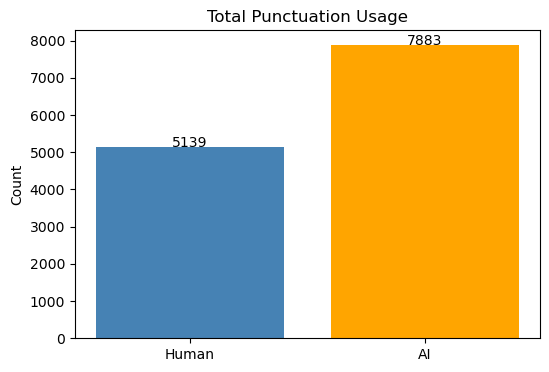

In [83]:
import matplotlib.pyplot as plt

labels = ["Human", "AI"]
values = [human_total, ai_total]

plt.figure(figsize=(6,4))
bars = plt.bar(labels, values, color=["steelblue","orange"])

plt.title("Total Punctuation Usage")
plt.ylabel("Count")

for bar in bars:
    plt.text(
        bar.get_x()+bar.get_width()/2,
        bar.get_height(),
        str(int(bar.get_height())),
        ha="center"
    )

plt.show()

In [35]:
!pip install textstat

Defaulting to user installation because normal site-packages is not writeable


In [84]:
import textstat
human_fre = textstat.flesch_reading_ease(human_text)
ai_fre = textstat.flesch_reading_ease(ai_text)

print("Human FRE:", human_fre)
print("AI FRE:", ai_fre)

Human FRE: 57.31430613438408
AI FRE: 20.55063307219453


In [85]:
human_fk = textstat.flesch_kincaid_grade(human_text)
ai_fk = textstat.flesch_kincaid_grade(ai_text)

print("Human FK Grade:", human_fk)
print("AI FK Grade:", ai_fk)

Human FK Grade: 10.377994797549125
AI FK Grade: 17.61886672732128


In [45]:
human_gf = textstat.gunning_fog(human_text)
ai_gf = textstat.gunning_fog(ai_text)

print("Human Gunning Fog:", human_gf)
print("AI Gunning Fog:", ai_gf)

Human Gunning Fog: 13.628877531534535
AI Gunning Fog: 20.75495409204318


In [46]:
human_ari = textstat.automated_readability_index(human_text)
ai_ari = textstat.automated_readability_index(ai_text)

print("Human ARI:", human_ari)
print("AI ARI:", ai_ari)

Human ARI: 11.93846505449931
AI ARI: 19.63498845381534


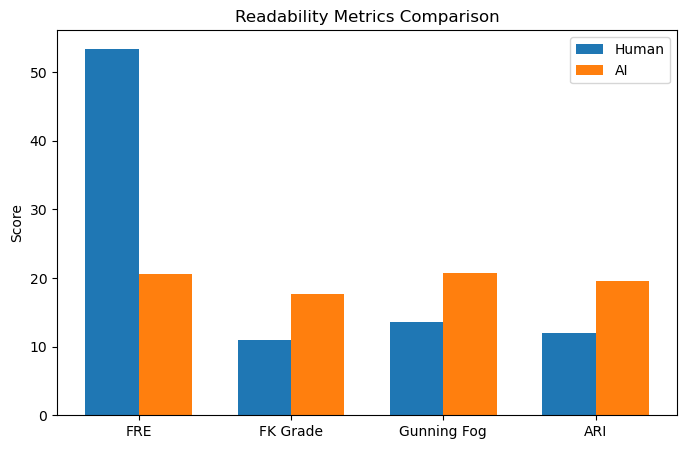

In [47]:
metrics = ["FRE", "FK Grade", "Gunning Fog", "ARI"]

human_scores = [human_fre, human_fk, human_gf, human_ari]
ai_scores = [ai_fre, ai_fk, ai_gf, ai_ari]

import numpy as np
import matplotlib.pyplot as plt

x = np.arange(len(metrics))
width = 0.35

plt.figure(figsize=(8,5))
plt.bar(x - width/2, human_scores, width, label="Human")
plt.bar(x + width/2, ai_scores, width, label="AI")

plt.xticks(x, metrics)
plt.ylabel("Score")
plt.title("Readability Metrics Comparison")
plt.legend()

plt.show()